# VJEPA Franka Trajectory File Explorer

This notebook analyzes the structure and content of the `franka_example_traj.npz` file used in the V-JEPA 2-AC examples. Understanding this file structure will help us create a compatible format for SO101 data.

In [1]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Define Analysis Functions

We'll define functions to explore and visualize the trajectory data.

In [2]:
def explore_franka_trajectory(file_path):
    """Comprehensive exploration of the Franka trajectory NPZ file"""
    
    print(f"Exploring: {file_path}")
    print("=" * 60)
    
    try:
        # Load the NPZ file
        with np.load(file_path) as data:
            print(f"File contains {len(data.keys())} arrays:\n")
            
            # Overview of all arrays
            for key in sorted(data.keys()):
                arr = data[key]
                print(f"  {key:20} | Shape: {str(arr.shape):15} | Type: {arr.dtype}")
            
            print("\n" + "=" * 60)
            
            # Detailed analysis of each array
            for key in sorted(data.keys()):
                arr = data[key]
                print(f"\nDetailed analysis of '{key}':")
                print(f"   Shape: {arr.shape}")
                print(f"   Data type: {arr.dtype}")
                print(f"   Memory size: {arr.nbytes / 1024:.1f} KB")
                
                if arr.size > 0:
                    if np.issubdtype(arr.dtype, np.number):
                        print(f"   Range: [{arr.min():.4f}, {arr.max():.4f}]")
                        print(f"   Mean: {arr.mean():.4f}, Std: {arr.std():.4f}")
                    
                    # Show sample data
                    if arr.size <= 20:
                        print(f"   Full data:\n   {arr}")
                    else:
                        if arr.ndim == 1:
                            print(f"   Sample (first 10): {arr[:10]}")
                        elif arr.ndim == 2:
                            print(f"   Sample (first few rows/cols):\n{arr[:3, :min(5, arr.shape[1])]}")
                        elif arr.ndim >= 3:
                            print(f"   Sample shape of first element: {arr[0].shape}")
                            if arr.ndim == 3 and arr.shape[0] <= 10:
                                print(f"   Sample from first frame: {arr[0, :3, :min(3, arr.shape[2])]}")
                
                print(f"   {'─' * 40}")
            
            # Create a dictionary to return with the actual numpy arrays
            return_data = {}
            for key in data.keys():
                return_data[key] = data[key].copy()
            
            return return_data
    
    except Exception as e:
        print(f"Error loading file: {e}")
        return None
    

def analyze_trajectory_structure(data):
    """Analyze if this looks like robotics trajectory data"""
    
    print(f"\nRobotics Trajectory Analysis:")
    print("=" * 60)
    
    # Common robotics data patterns
    trajectory_indicators = []
    
    for key in data.keys():
        arr = data[key]
        
        # Check for common trajectory data patterns
        if 'action' in key.lower():
            trajectory_indicators.append(f"'{key}' likely contains robot actions")
        elif 'obs' in key.lower() or 'observation' in key.lower():
            trajectory_indicators.append(f"'{key}' likely contains observations")
        elif 'state' in key.lower():
            trajectory_indicators.append(f"'{key}' likely contains robot state")
        elif 'reward' in key.lower():
            trajectory_indicators.append(f"'{key}' likely contains rewards")
        elif 'image' in key.lower() or 'rgb' in key.lower():
            trajectory_indicators.append(f"'{key}' likely contains camera images")
        elif arr.ndim >= 2 and arr.shape[0] > 10:  # Time series
            trajectory_indicators.append(f"'{key}' has time-series structure ({arr.shape[0]} timesteps)")
    
    if trajectory_indicators:
        print("Detected trajectory patterns:")
        for indicator in trajectory_indicators:
            print(f"   - {indicator}")
    else:
        print("No obvious trajectory patterns detected")
    
    # Look for temporal dimension
    print(f"\nTemporal analysis:")
    max_length = 0
    temporal_arrays = []
    
    for key in data.keys():
        arr = data[key]
        if arr.ndim >= 1 and arr.shape[0] > max_length:
            max_length = arr.shape[0]
            temporal_arrays.append((key, arr.shape[0]))
    
    if temporal_arrays:
        print(f"   Likely trajectory length: {max_length} timesteps")
        print(f"   Arrays with temporal dimension:")
        for key, length in temporal_arrays:
            print(f"     - {key}: {length} timesteps")

def visualize_trajectory_data(data):
    """Create visualizations if the data looks like trajectory data"""
    
    print(f"\nGenerating visualizations...")
    
    # Process and prepare arrays for plotting
    plottable_arrays = {}
    
    for key in data.keys():
        arr = data[key]
        
        # Skip non-numeric arrays
        if not np.issubdtype(arr.dtype, np.number):
            continue
            
        # Process based on dimensionality
        if arr.ndim == 1:
            # 1D array can be plotted directly
            plottable_arrays[f"{key}"] = arr
        elif arr.ndim == 2:
            # 2D array can be plotted directly
            plottable_arrays[f"{key}"] = arr
        elif arr.ndim == 3:
            # For 3D arrays, extract 2D slices
            if arr.shape[2] <= 10:  # If last dimension is small enough
                for i in range(arr.shape[2]):
                    plottable_arrays[f"{key}_dim{i}"] = arr[:, :, i]
            else:
                # Just take the first slice
                plottable_arrays[f"{key}_slice0"] = arr[:, :, 0]
        elif arr.ndim >= 4:
            # For higher dimensional arrays, extract sequences
            # For states: shape (1, 2, 7)
            if 'state' in key.lower() and arr.shape[-1] == 7:
                # Reshape to get a sequence of state vectors
                flattened = arr.reshape(-1, arr.shape[-1])
                plottable_arrays[f"{key}_flattened"] = flattened
            
            # For observations: shape (1, 2, 256, 256, 3)
            elif 'observation' in key.lower() or arr.ndim == 5:
                # For image data, take first sample and show RGB channels separately
                sample = arr[0] if arr.shape[0] == 1 else arr
                # Extract a reduced representation (mean over spatial dimensions)
                if sample.shape[-1] == 3:  # RGB
                    # Mean intensity over time for R,G,B channels
                    r_mean = np.mean(sample[:, :, :, 0], axis=(1, 2))
                    g_mean = np.mean(sample[:, :, :, 1], axis=(1, 2))
                    b_mean = np.mean(sample[:, :, :, 2], axis=(1, 2))
                    rgb_means = np.stack([r_mean, g_mean, b_mean], axis=1)
                    plottable_arrays[f"{key}_rgb_means"] = rgb_means
    
    if not plottable_arrays:
        print("   No suitable arrays found for plotting")
        return
    
    # Create plots
    n_plots = min(len(plottable_arrays), 6)  # Max 6 plots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (key, arr) in enumerate(list(plottable_arrays.items())[:n_plots]):
        ax = axes[i]
        
        if arr.ndim == 1:
            ax.plot(arr)
            ax.set_title(f'{key} (1D)')
            ax.set_xlabel('Index')
        elif arr.ndim == 2:
            if arr.shape[1] <= 10:  # Plot multiple dimensions
                for j in range(min(arr.shape[1], 5)):
                    ax.plot(arr[:, j], label=f'dim_{j}')
                ax.legend()
                ax.set_title(f'{key} (multi-dim)')
                ax.set_xlabel('Timestep')
            else:  # Show as heatmap
                im = ax.imshow(arr.T, aspect='auto', cmap='viridis')
                ax.set_title(f'{key} (heatmap)')
                ax.set_xlabel('Timestep')
                ax.set_ylabel('Dimension')
                plt.colorbar(im, ax=ax)
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    return fig

## Load and Analyze the Franka Trajectory File

We'll load and analyze the file structure of `franka_example_traj.npz` to understand its format.

In [3]:
from lerobot_so_arm.config import get_path

file_path = get_path('vjepa_root') + "/notebooks/franka_example_traj.npz"

print("VJEPA Franka Trajectory Explorer")
print("Analyzing franka_example_traj.npz...")

data = explore_franka_trajectory(file_path)

VJEPA Franka Trajectory Explorer
Analyzing franka_example_traj.npz...
Exploring: /Users/michelmeyer/.local/dev/vjepa2-so_arm/notebooks/franka_example_traj.npz
File contains 2 arrays:

  observations         | Shape: (1, 2, 256, 256, 3) | Type: uint8
  states               | Shape: (1, 2, 7)       | Type: float32


Detailed analysis of 'observations':
   Shape: (1, 2, 256, 256, 3)
   Data type: uint8
   Memory size: 384.0 KB
   Range: [0.0000, 255.0000]
   Mean: 130.4614, Std: 67.1925
   Sample shape of first element: (2, 256, 256, 3)
   ────────────────────────────────────────

Detailed analysis of 'states':
   Shape: (1, 2, 7)
   Data type: float32
   Memory size: 0.1 KB
   Range: [-3.0666, 0.9970]
   Mean: -0.4315, Std: 1.3726
   Full data:
   [[[ 5.8043909e-01 -2.0212342e-03  2.4755727e-01 -3.0666156e+00
    3.0529797e-02 -1.9127512e+00  9.9697137e-01]
  [ 6.7280847e-01  2.8965971e-02  3.3183685e-01 -3.0514374e+00
    1.7709509e-02 -1.9124950e+00  9.9697137e-01]]]
   ───────────────

## Analyze Trajectory Structure

Now let's look more specifically at the structure of the data and determine if it matches the expected format for robotics trajectories.

In [4]:
if data:
    analyze_trajectory_structure(data)


Robotics Trajectory Analysis:
Detected trajectory patterns:
   - 'observations' likely contains observations
   - 'states' likely contains robot state

Temporal analysis:
   Likely trajectory length: 1 timesteps
   Arrays with temporal dimension:
     - observations: 1 timesteps


## Visualize Trajectory Data

Creating visualizations of key arrays can help us understand the data better.

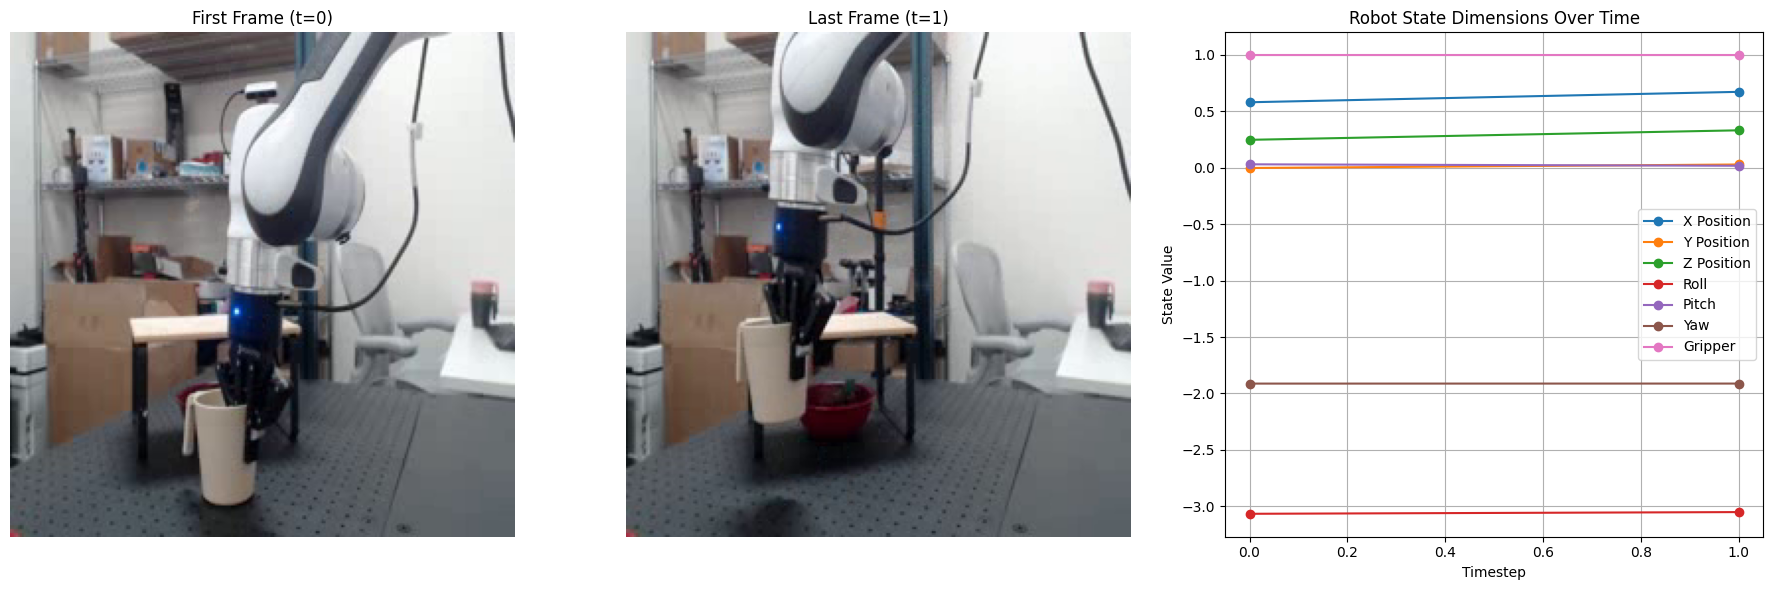


State values at each timestep:

Timestep 0:
  X Position: 0.5804
  Y Position: -0.0020
  Z Position: 0.2476
  Roll      : -3.0666
  Pitch     : 0.0305
  Yaw       : -1.9128
  Gripper   : 0.9970

Timestep 1:
  X Position: 0.6728
  Y Position: 0.0290
  Z Position: 0.3318
  Roll      : -3.0514
  Pitch     : 0.0177
  Yaw       : -1.9125
  Gripper   : 0.9970


In [5]:
if data:
    # Create figure with subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. First image (first timestep)
    first_img = data['observations'][0, 0]  # Batch 0, Time 0
    axs[0].imshow(first_img)
    axs[0].set_title('First Frame (t=0)')
    axs[0].axis('off')
    
    # 2. Last image (last timestep)
    last_img = data['observations'][0, -1]  # Batch 0, Last frame
    axs[1].imshow(last_img)
    axs[1].set_title(f'Last Frame (t={data["observations"].shape[1]-1})')
    axs[1].axis('off')
    
    # 3. State dimensions over time
    states = data['states'][0]  # Get states for batch 0
    timesteps = range(states.shape[0])
    
    # Define labels for the state dimensions
    state_labels = ['X Position', 'Y Position', 'Z Position', 
                    'Roll', 'Pitch', 'Yaw', 'Gripper']
    
    # Plot each dimension of the state
    for i in range(states.shape[1]):
        axs[2].plot(timesteps, states[:, i], marker='o', label=state_labels[i])
    
    axs[2].set_xlabel('Timestep')
    axs[2].set_ylabel('State Value')
    axs[2].set_title('Robot State Dimensions Over Time')
    axs[2].legend()
    axs[2].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Optional: Display individual state values at each timestep
    print("\nState values at each timestep:")
    for t in range(states.shape[0]):
        print(f"\nTimestep {t}:")
        for i in range(states.shape[1]):
            print(f"  {state_labels[i]:10}: {states[t, i]:.4f}")